In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


In [3]:
def prepare_composite_data(w500, var_dataset, varname, years, ocean_mask, months=[4, 5, 6, 7, 8, 9], bin_count=10):

    w_climatology = w500.sel(time=slice('1991', '2020')).where(
        w500.time.dt.month.isin(months)
    ).mean('time')

    w_flat = w_climatology['w'].values.flatten()
    w_flat = w_flat[~np.isnan(w_flat)]
    quantile_centers = np.linspace(0.05, 0.95, bin_count)
    bin_centers = np.quantile(w_flat, quantile_centers)

    edges = np.zeros(len(bin_centers) + 1)
    edges[1:-1] = (bin_centers[:-1] + bin_centers[1:]) / 2
    edges[0] = w_flat.min() - 1e-6
    edges[-1] = w_flat.max() + 1e-6

    all_data = []
    for year in years:
        year_str = str(year)
        prev_year_str = str(year - 1)

        var_this = var_dataset[varname].sel(time=slice(f'{year_str}-04', f'{year_str}-09')).mean('time')
        var_prev = var_dataset[varname].sel(time=slice(f'{prev_year_str}-04', f'{prev_year_str}-09')).mean('time')
        delta_var = var_this - var_prev

        w_values = w_climatology['w'].values
        delta_values = delta_var.values
        valid_mask = ~np.isnan(delta_values) & ~np.isnan(w_values)

        w_clean = w_values[valid_mask]
        delta_clean = delta_values[valid_mask]

        bin_indices = np.digitize(w_clean, bins=edges)
        year_data = pd.DataFrame({
            'Year': year,
            'Bin': bin_indices,
            'Bin Center': [bin_centers[i - 1] if 0 < i <= len(bin_centers) else np.nan for i in bin_indices],
            'Delta Var': delta_clean
        })
        year_data.dropna(inplace=True)
        all_data.append(year_data)

    return pd.concat(all_data, ignore_index=True)


In [4]:
def aggregate_composite_data(data):
    grouped = data.groupby('Bin Center')['Delta Var'].agg(['mean', 'std']).reset_index()
    grouped.columns = ['Bin Center', 'Delta Mean', 'Delta Std']
    return grouped


In [5]:
def plot_composite_bins(grouped_comp, grouped_year, var_label='ΔVar [units]', legend = True):
    fig, ax = plt.subplots(figsize=(6, 5))
    offset = 1.2

    composite_x = grouped_comp['Bin Center'] - offset
    year_x = grouped_year['Bin Center'] + offset

    ax.errorbar(
        composite_x,
        grouped_comp['Delta Mean'],
        yerr=grouped_comp['Delta Std'],
        fmt='o', capsize=4, label='Composite', color='k',
        markersize = 8
    )

    ax.errorbar(
        year_x,
        grouped_year['Delta Mean'],
        yerr=grouped_year['Delta Std'],
        fmt='o', capsize=4, label='2023', color='red',
        markersize = 8
    )

    ax.set_xlim(-60, 35)
    if 'SST' in var_label:
        ax.set_ylim(-1, 3.)
    elif 'CC' in var_label:
        ax.set_ylim(-.16, .16)
    ax.set_xlabel('w₅₀₀ [hPa/day]', fontsize=18, fontweight='normal')
    ax.set_ylabel(var_label, fontsize=18, fontweight='normal')
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(axis='y')

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=2.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=2.5)

    if legend: ax.legend(fontsize=12, loc = 'lower right')
    plt.tight_layout()
    plt.show()


In [6]:
def run_composite_analysis(w500, dataset, varname, ocean_mask, composite_years, target_year=2023, var_label=None, legend = True):
    if var_label is None:
        var_label = f'Δ{varname.upper()} [units]'

    comp_data = prepare_composite_data(w500, dataset, varname, composite_years, ocean_mask)
    target_data = prepare_composite_data(w500, dataset, varname, [target_year], ocean_mask)

    comp_grouped = aggregate_composite_data(comp_data)
    target_grouped = aggregate_composite_data(target_data)

    plot_composite_bins(comp_grouped, target_grouped, var_label=var_label, legend = legend)


## Load Data

In [7]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

In [8]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20, -20), time = slice('1979', None))
sst = sst.where(ocean_mask)



In [9]:

fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-02'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

clouds = clouds.where(ocean_mask)

In [10]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20), time= slice('1979', None))

w500 = w500.where(ocean_mask)
#convert to hpa/day
w500 = w500*(24*3600/100)




## Computation

In [11]:
composite_years = [1982, 1987, 1991, 1997, 2009, 2015]

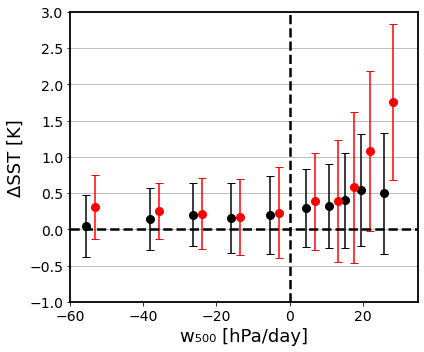

In [12]:
run_composite_analysis(w500, sst, 'sst', ocean_mask, composite_years=composite_years, var_label='ΔSST [K]', legend = False)

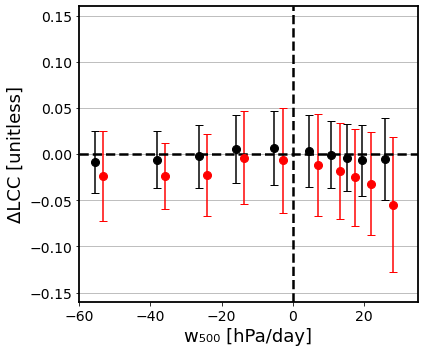

In [13]:
run_composite_analysis(w500, clouds, 'lcc', ocean_mask, composite_years=composite_years, var_label='ΔLCC [unitless]', legend = False)

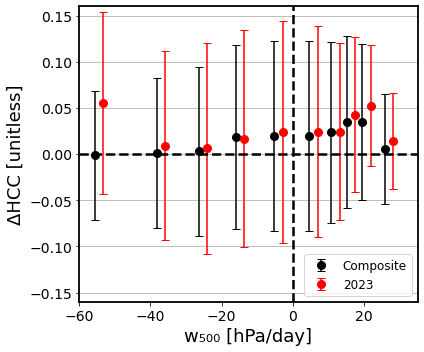

In [14]:
run_composite_analysis(w500, clouds, 'hcc', ocean_mask, composite_years=composite_years, var_label='ΔHCC [unitless]')